# 📊 Notebook 1 — Exploratory Data Analysis (EDA)
**Project:** Smartphone Addiction Prediction  
**Goal:** Understand the dataset structure, distributions, and relationships before any modeling.

---

## 1. Imports & Configuration

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/Smartphone_Usage_And_Addiction.csv'

## 2. Load Data

In [19]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## 3. Dataset Overview

In [20]:
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe(include='all').T

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  add

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,7500,7500,TXN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,7500,7500,U00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7500.0,NaN,NaN,NaN,26.5688,5.197108,18.0,22.0,27.0,31.0,35.0
gender,7500,3,Male,2553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_screen_time_hours,7500.0,NaN,NaN,NaN,7.499912,2.609188,3.0,5.22,7.525,9.81,12.0
social_media_hours,7500.0,NaN,NaN,NaN,3.273484,1.585342,0.5,1.91,3.27,4.63,6.0
gaming_hours,7500.0,NaN,NaN,NaN,2.014183,1.146039,0.0,1.02,2.04,2.99,4.0
work_study_hours,7500.0,NaN,NaN,NaN,3.24242,1.600765,0.5,1.85,3.23,4.64,6.0
sleep_hours,7500.0,NaN,NaN,NaN,6.737561,1.283605,4.5,5.63,6.72,7.84,9.0
notifications_per_day,7500.0,NaN,NaN,NaN,134.257333,66.586883,20.0,76.0,134.0,191.0,250.0


In [21]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

=== Missing Values ===


,Missing Count,Missing %
addiction_level,819,10.92


In [22]:
print('=== Duplicate Rows ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Duplicate Rows ===
Duplicate rows: 0


## 4. Target Variable Analysis

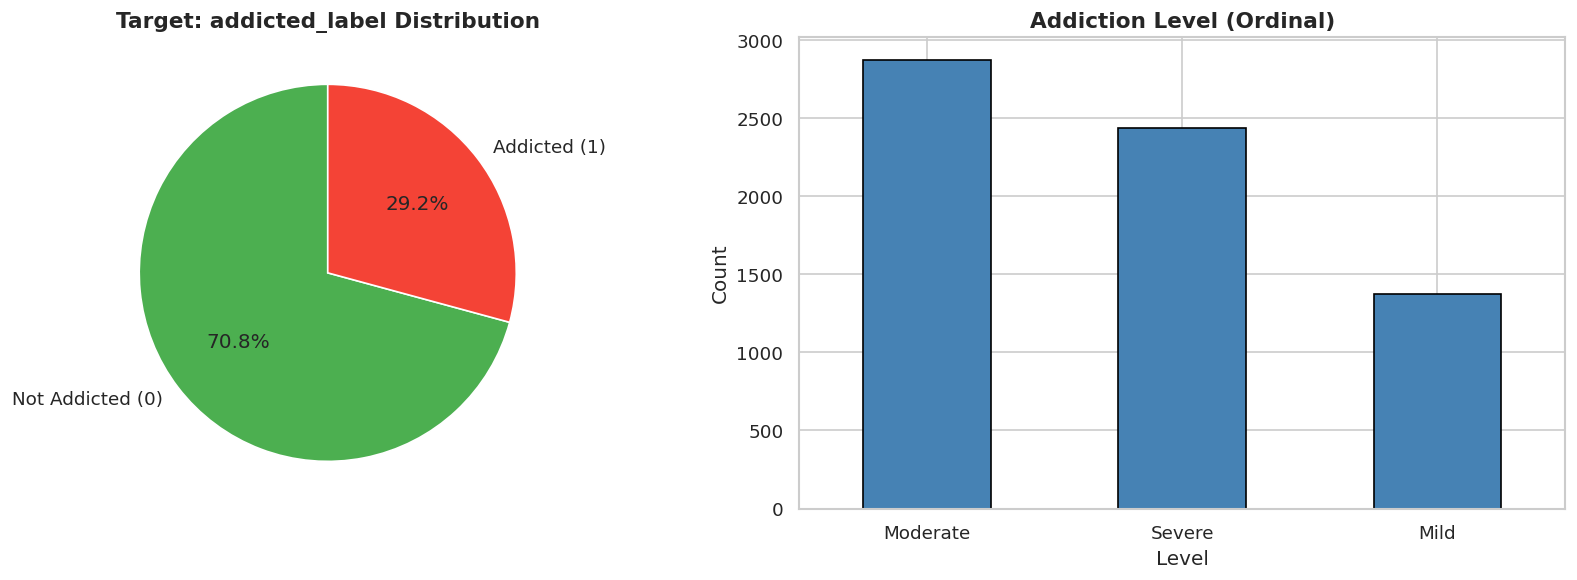

addicted_label
1    5308
0    2192
Name: count, dtype: int64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target
target_counts = df['addicted_label'].value_counts()
axes[0].pie(target_counts, labels=['Not Addicted (0)', 'Addicted (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Target: addicted_label Distribution', fontsize=13, fontweight='bold')

# Ordinal target
if 'addiction_level' in df.columns:
    df['addiction_level'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].set_title('Addiction Level (Ordinal)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Level')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(target_counts)

## 5. Numerical Features — Distributions

Numerical features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


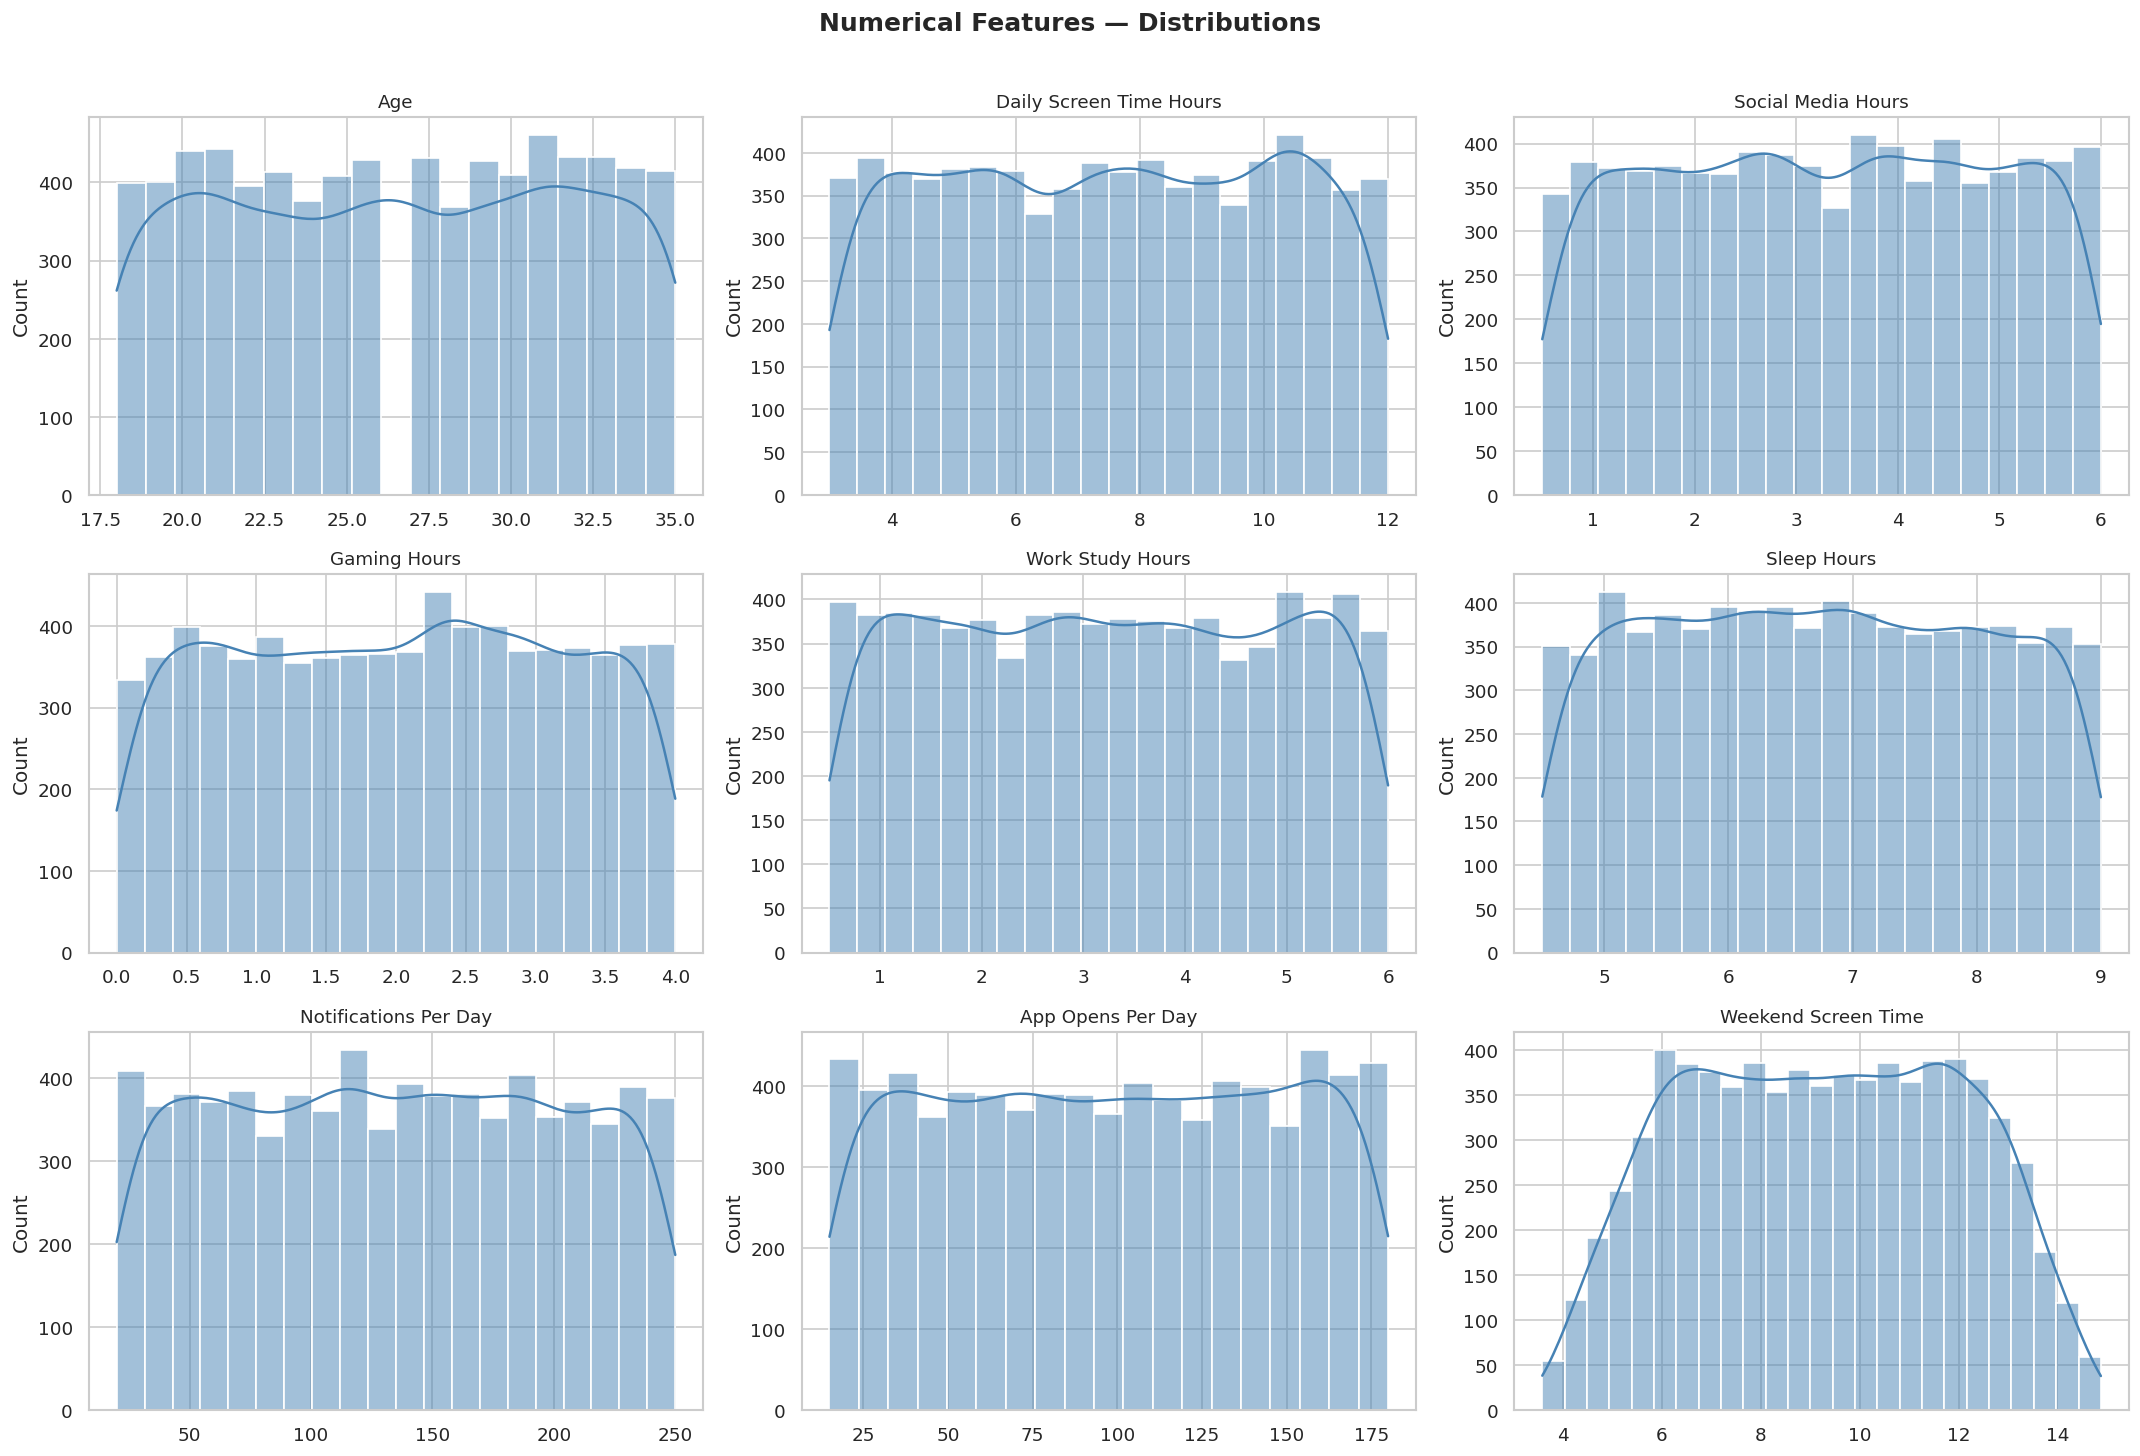

In [24]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove ID-like and target columns
drop_from_analysis = ['transaction_id', 'user_id', 'addicted_label']
num_features = [c for c in num_cols if c not in drop_from_analysis]
print(f'Numerical features: {num_features}')

n = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features — Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Numerical Features vs Target (Box Plots)

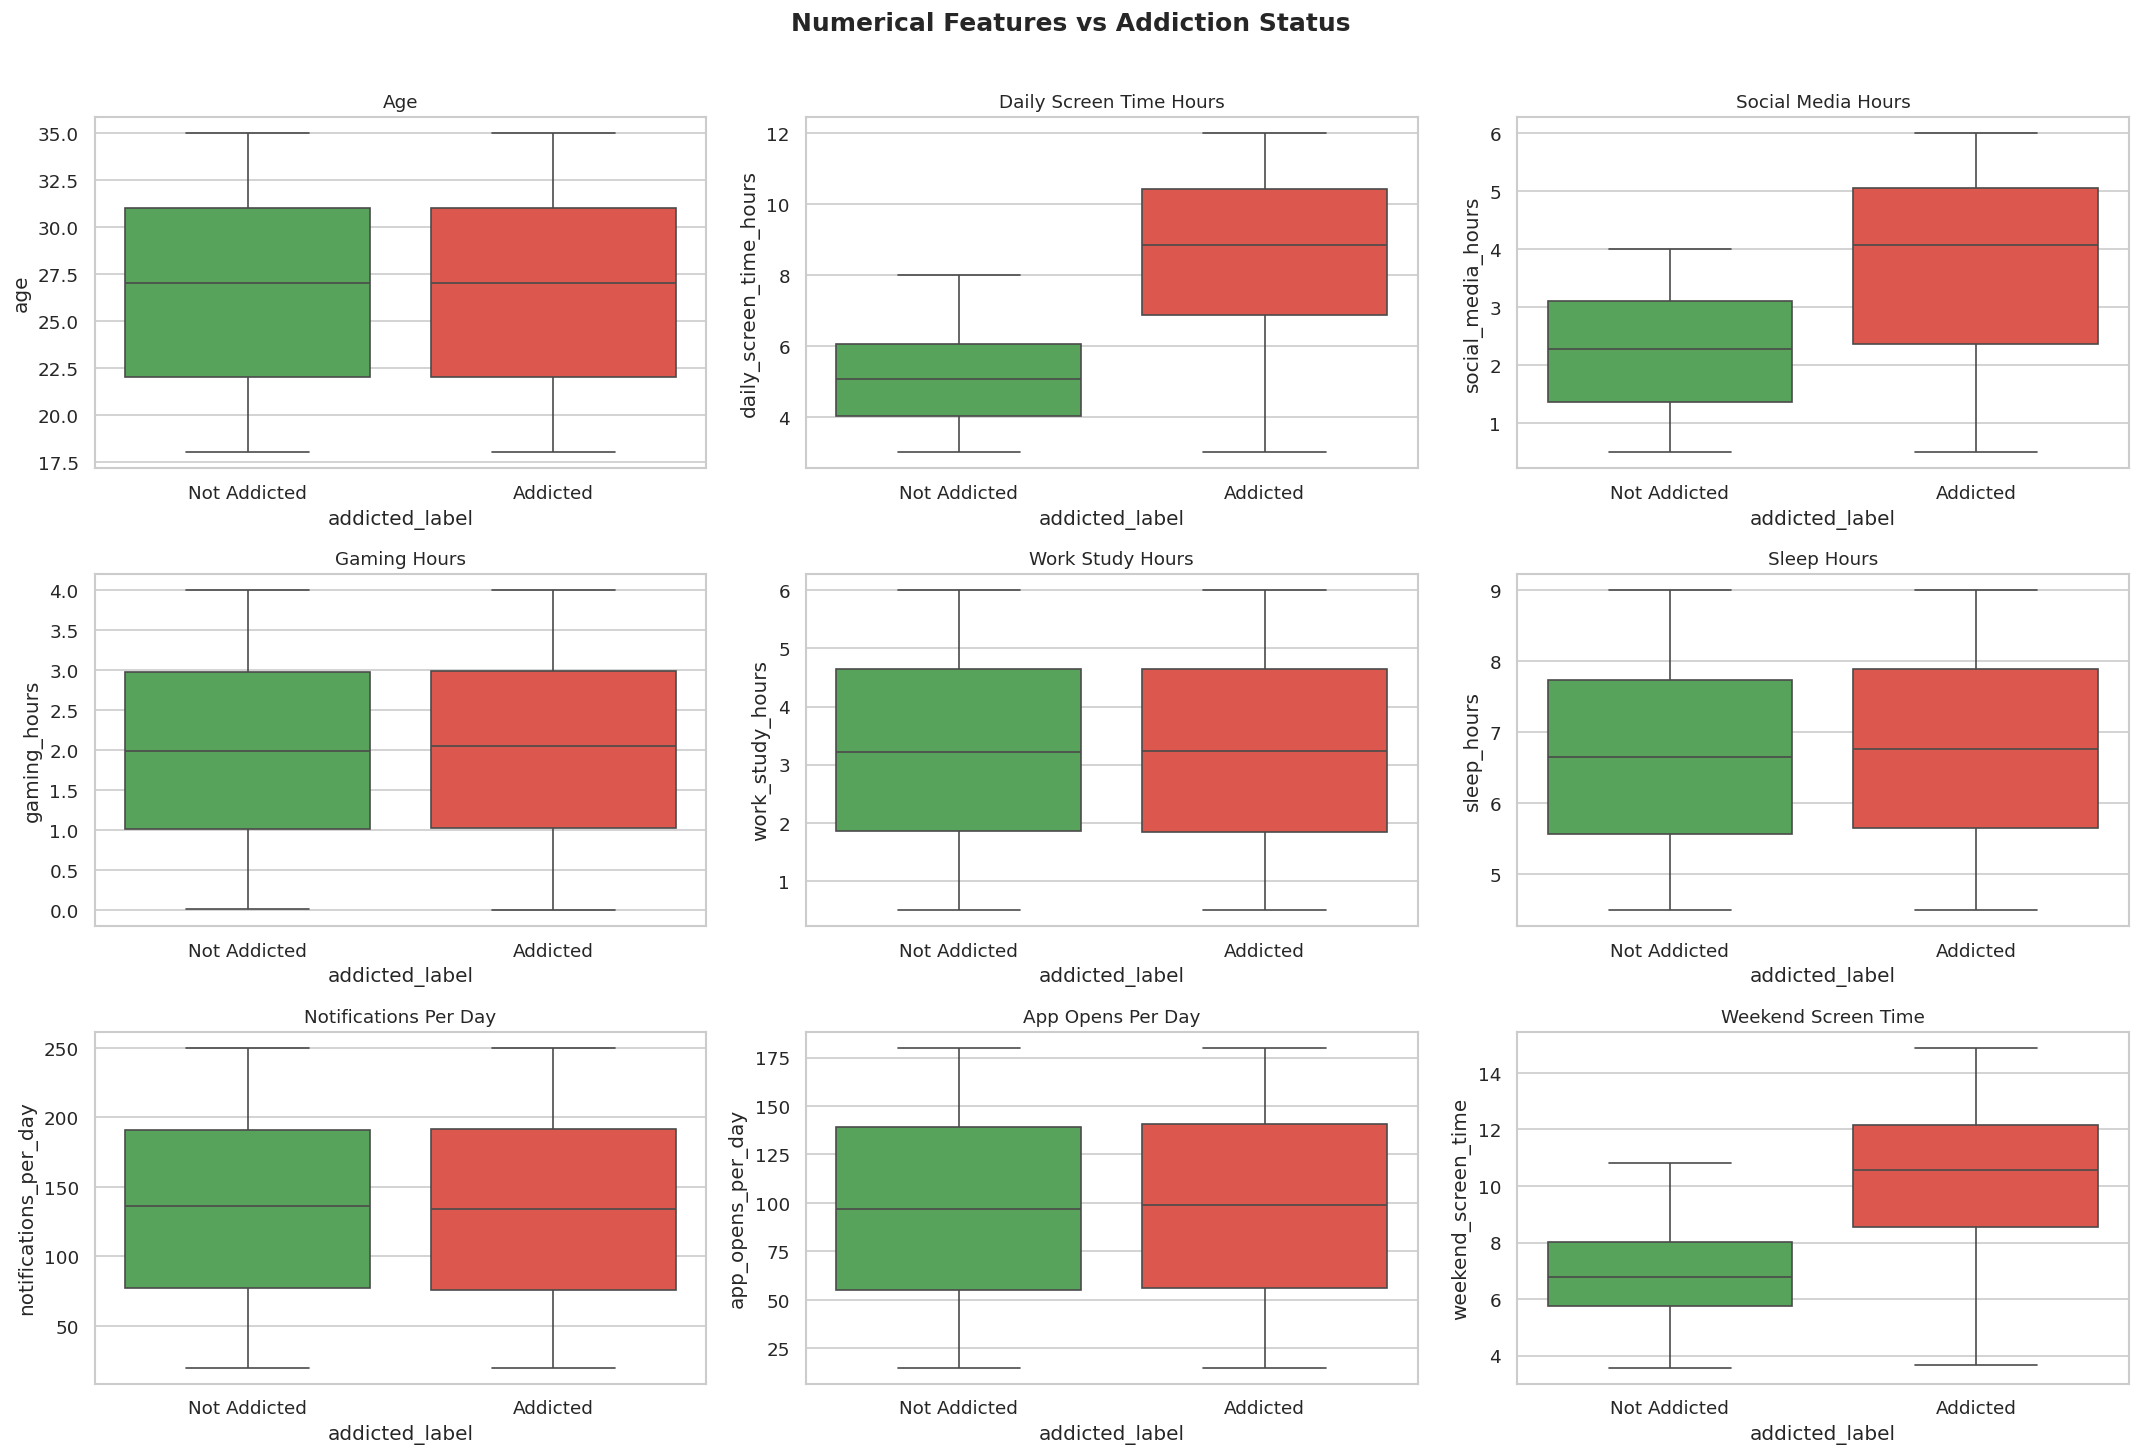

In [25]:
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x='addicted_label', y=col, data=df, ax=axes[i],
                palette=['#4CAF50', '#F44336'])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xticklabels(['Not Addicted', 'Addicted'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Addiction Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Categorical Features

Categorical features: ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']


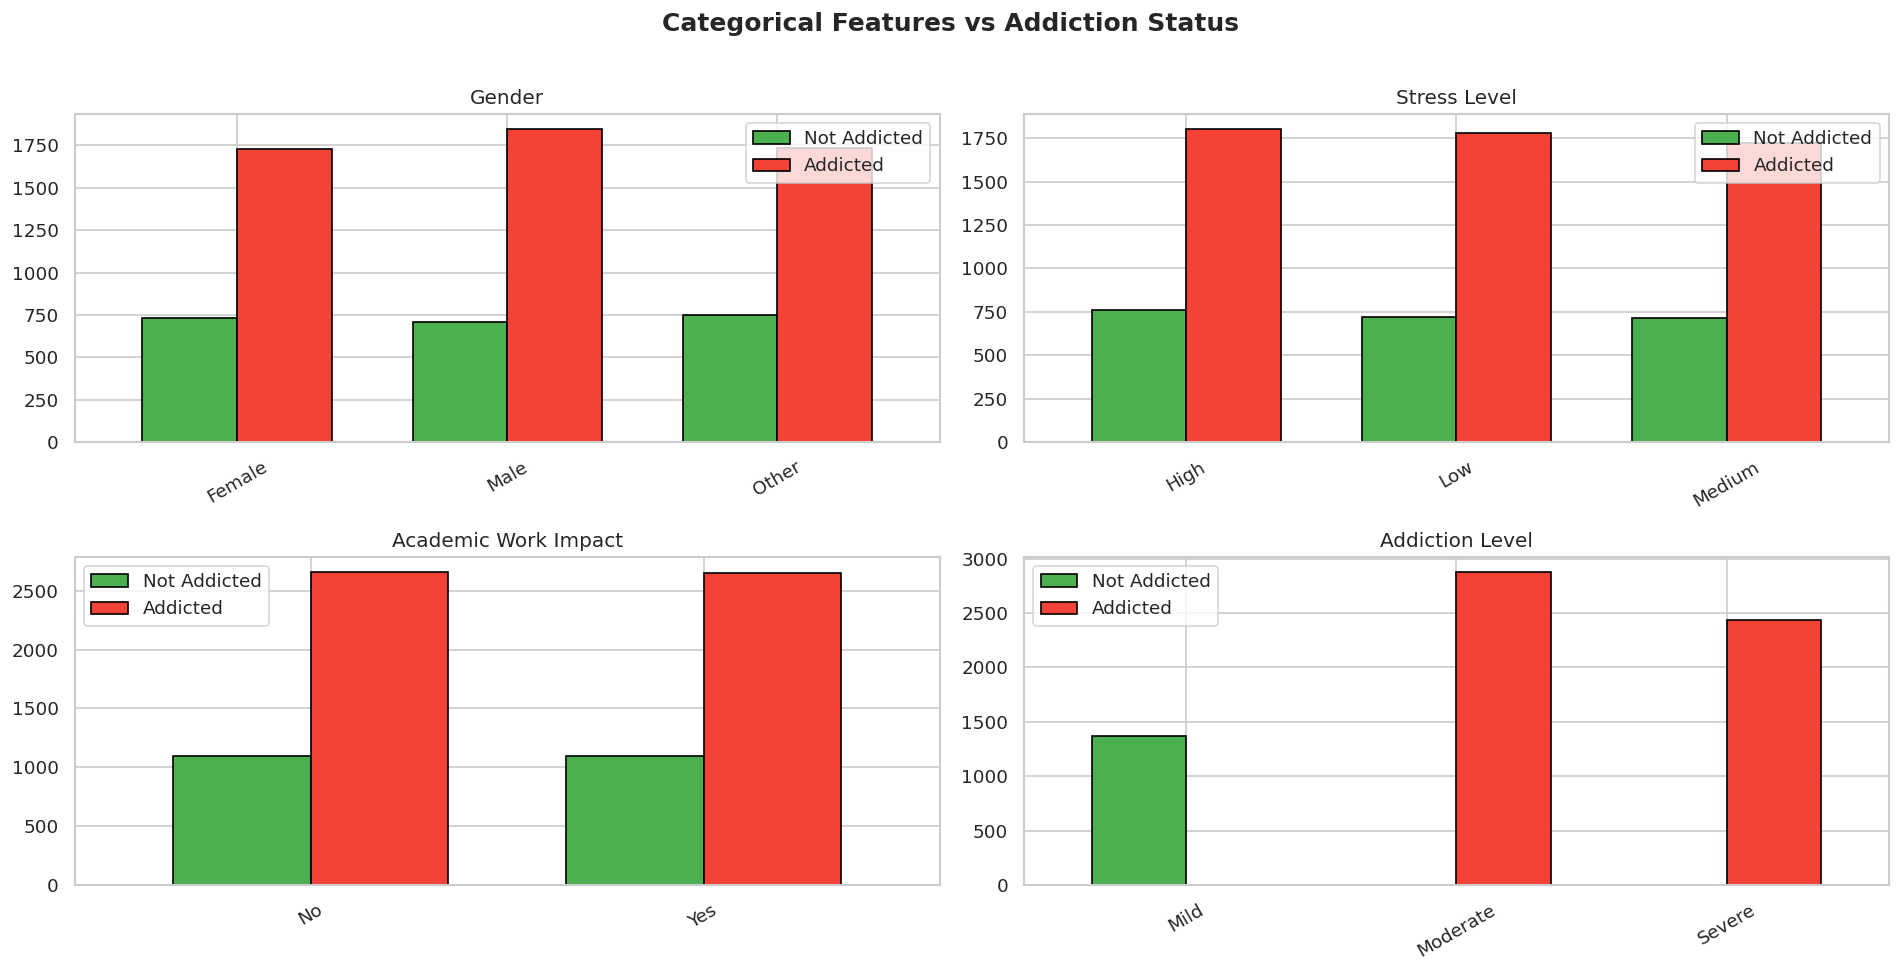

In [26]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
id_cols = [c for c in cat_cols if 'id' in c.lower()]
cat_features = [c for c in cat_cols if c not in id_cols]
print(f'Categorical features: {cat_features}')

n_cat = len(cat_features)
cols_cat = 2
rows_cat = (n_cat + cols_cat - 1) // cols_cat

fig, axes = plt.subplots(rows_cat, cols_cat, figsize=(16, rows_cat * 4))
axes = axes.flatten() if n_cat > 1 else [axes]

for i, col in enumerate(cat_features):
    val_counts = df.groupby([col, 'addicted_label']).size().unstack(fill_value=0)
    val_counts.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
                    edgecolor='black', width=0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Not Addicted', 'Addicted'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Addiction Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

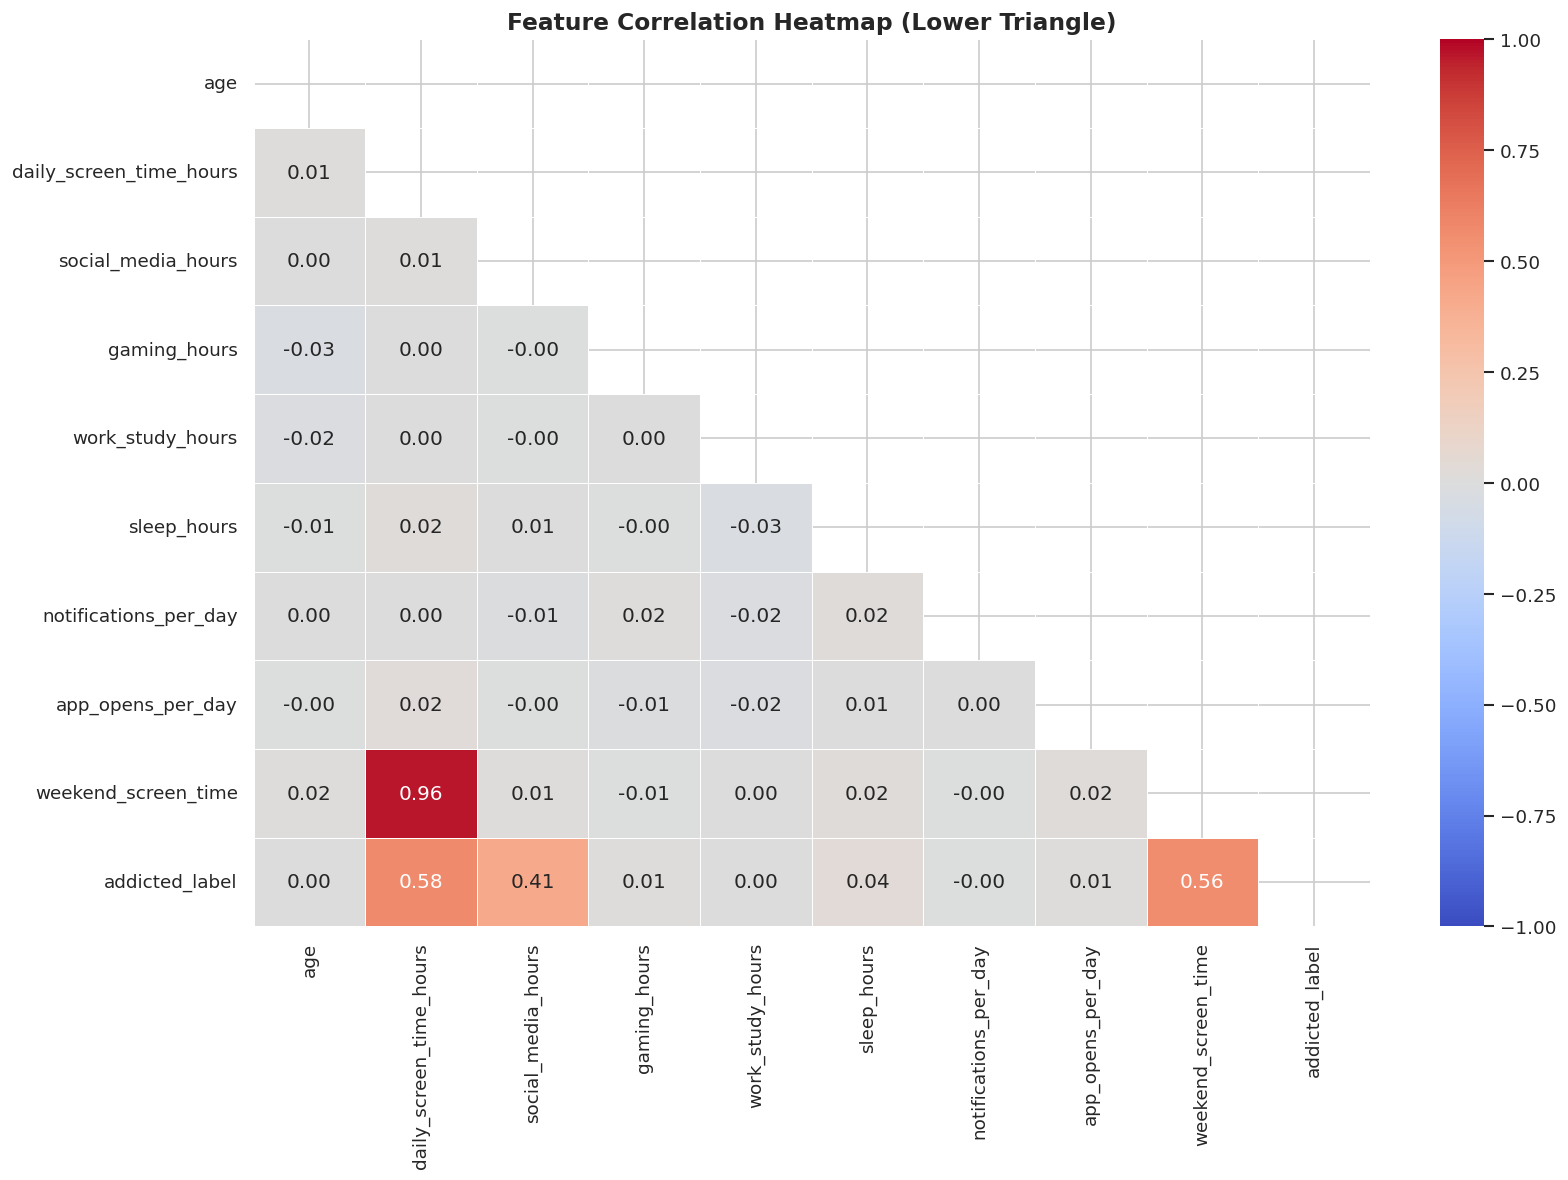


=== Correlation with Target (addicted_label) ===
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
notifications_per_day     -0.000660
Name: addicted_label, dtype: float64


In [27]:
corr_df = df[num_features + ['addicted_label']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Correlation with Target (addicted_label) ===')
corr_with_target = corr_df['addicted_label'].drop('addicted_label').sort_values(key=abs, ascending=False)
print(corr_with_target)

## 9. Outlier Detection

In [28]:
print('=== IQR-Based Outlier Summary ===')
outlier_summary = []
for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Outlier Count': n_out,
                             'Outlier %': round(n_out / len(df) * 100, 2)})

pd.DataFrame(outlier_summary).set_index('Feature')

=== IQR-Based Outlier Summary ===


,Outlier Count,Outlier %
Feature,,
age,0,0.0
daily_screen_time_hours,0,0.0
social_media_hours,0,0.0
gaming_hours,0,0.0
work_study_hours,0,0.0
sleep_hours,0,0.0
notifications_per_day,0,0.0
app_opens_per_day,0,0.0
weekend_screen_time,0,0.0


## 10. EDA Summary

| Finding | Detail |
|---------|--------|
| Dataset shape | *Filled after run* |
| Missing values | *Filled after run* |
| Class balance | *Filled after run* |
| Top correlated feature | *Filled after run* |
| Key observations | Screen time & social media hours are strongest predictors |